# Reemplazo y segmentanción de jugadores de fútbol

Aplicando similitud de coseno y PCA (análisis de componentes principales)

Importando librerías principales

In [90]:
import pandas as pd
import numpy as np

## Importando el dataset de Kaggle

In [91]:
import kagglehub
import os

Datos estadísticos de jugadores por 90 minutos

In [92]:
path_kaggle_stats= kagglehub.dataset_download("vivovinco/20222023-football-player-stats")
players_stats_csv = os.path.join(path_kaggle_stats, "2022-2023 Football Player Stats.csv")
players_stats_df = pd.read_csv(players_stats_csv, encoding='latin-1', sep=';')
print(players_stats_df.head())

   Rk             Player Nation   Pos         Squad            Comp  Age  \
0   1   Brenden Aaronson    USA  MFFW  Leeds United  Premier League   22   
1   2   Yunis Abdelhamid    MAR    DF         Reims         Ligue 1   35   
2   3      Himad Abdelli    FRA  MFFW        Angers         Ligue 1   23   
3   4  Salis Abdul Samed    GHA    MF          Lens         Ligue 1   22   
4   5    Laurent Abergel    FRA    MF       Lorient         Ligue 1   30   

   Born  MP  Starts  ...   Off   Crs  TklW  PKwon  PKcon    OG  Recov  AerWon  \
0  2000  20      19  ...  0.17  2.54  0.51    0.0    0.0  0.00   4.86    0.34   
1  1987  22      22  ...  0.05  0.18  1.59    0.0    0.0  0.00   6.64    2.18   
2  1999  14       8  ...  0.00  1.05  1.40    0.0    0.0  0.00   8.14    0.93   
3  2000  20      20  ...  0.00  0.35  0.80    0.0    0.0  0.05   6.60    0.50   
4  1993  15      15  ...  0.00  0.23  2.02    0.0    0.0  0.00   6.51    0.31   

   AerLost  AerWon%  
0     1.19     22.2  
1     1.23  

Datos de los jugadores según Transfermarkt

In [93]:
path_kaggle_players = kagglehub.dataset_download("davidcariboo/player-scores/versions/585")
players_csv = os.path.join(path_kaggle_players, "players.csv")
players_df = pd.read_csv(players_csv)
print(players_df.head())

   player_id first_name     last_name                name  last_season  \
0         10   Miroslav         Klose      Miroslav Klose         2015   
1         26      Roman  Weidenfeller  Roman Weidenfeller         2017   
2         65    Dimitar      Berbatov    Dimitar Berbatov         2015   
3         77        NaN         Lúcio               Lúcio         2012   
4         80        Tom        Starke          Tom Starke         2017   

   current_club_id         player_code    country_of_birth city_of_birth  \
0              398      miroslav-klose              Poland         Opole   
1               16  roman-weidenfeller             Germany          Diez   
2             1091    dimitar-berbatov            Bulgaria   Blagoevgrad   
3              506               lucio              Brazil      Brasília   
4               27          tom-starke  East Germany (GDR)       Freital   

  country_of_citizenship  ...   foot height_in_cm contract_expiration_date  \
0                Ger

Información de cada dato estadístico de cada jugador

In [94]:
feature_descriptions = {
    "Rk": "Ranking",
    "Player": "Nombre del jugador",
    "Nation": "Nacionalidad del jugador",
    "Pos": "Posición",
    "Squad": "Nombre del equipo",
    "Comp": "Liga en la que compite el equipo",
    "Age": "Edad del jugador",
    "Born": "Año de nacimiento",
    "MP": "Partidos jugados",
    "Starts": "Partidos como titular",
    "Min": "Minutos jugados",
    "90s": "Minutos jugados divididos entre 90",
    "Goals": "Goles anotados o recibidos",
    "Shots": "Tiros totales (sin penales)",
    "SoT": "Tiros al arco (sin penales)",
    "SoT%": "Porcentaje de tiros al arco (sin penales)",
    "G/Sh": "Goles por tiro",
    "G/SoT": "Goles por tiro al arco (sin penales)",
    "ShoDist": "Distancia promedio en yardas desde donde se realizaron los tiros (sin penales)",
    "ShoFK": "Tiros desde tiros libres",
    "ShoPK": "Penales convertidos",
    "PKatt": "Penales intentados",
    "PasTotCmp": "Pases completados",
    "PasTotAtt": "Pases intentados",
    "PasTotCmp%": "Porcentaje de pases completados",
    "PasTotDist": "Distancia total en yardas de los pases completados en cualquier dirección",
    "PasTotPrgDist": "Distancia total en yardas de los pases completados hacia el arco rival",
    "PasShoCmp": "Pases completados (entre 5 y 15 yardas)",
    "PasShoAtt": "Pases intentados (entre 5 y 15 yardas)",
    "PasShoCmp%": "Porcentaje de pases completados (entre 5 y 15 yardas)",
    "PasMedCmp": "Pases completados (entre 15 y 30 yardas)",
    "PasMedAtt": "Pases intentados (entre 15 y 30 yardas)",
    "PasMedCmp%": "Porcentaje de pases completados (entre 15 y 30 yardas)",
    "PasLonCmp": "Pases completados (más de 30 yardas)",
    "PasLonAtt": "Pases intentados (más de 30 yardas)",
    "PasLonCmp%": "Porcentaje de pases completados (más de 30 yardas)",
    "Assists": "Asistencias",
    "PasAss": "Pases que conducen directamente a un tiro",
    "Pas3rd": "Pases completados que ingresan al último tercio del campo",
    "PPA": "Pases completados al área de penal",
    "CrsPA": "Centros completados al área de penal",
    "PasProg": "Pases completados que avanzan al menos 10 yardas hacia el arco rival o ingresan al área",
    "PasAtt": "Pases intentados",
    "PasLive": "Pases en jugada viva",
    "PasDead": "Pases en jugada detenida",
    "PasFK": "Pases desde tiros libres",
    "TB": "Pase completado entre defensores hacia espacio libre",
    "Sw": "Pases que cruzan más de 40 yardas de ancho del campo",
    "PasCrs": "Centros",
    "TI": "Saques de banda realizados",
    "CK": "Tiros de esquina",
    "CkIn": "Tiros de esquina con efecto hacia adentro",
    "CkOut": "Tiros de esquina con efecto hacia afuera",
    "CkStr": "Tiros de esquina rectos",
    "PasCmp": "Pases completados",
    "PasOff": "Fuera de juego",
    "PasBlocks": "Bloqueado por el oponente en la trayectoria del pase",
    "SCA": "Acciones que generan tiros",
    "ScaPassLive": "Pases en jugada viva que conducen a un tiro",
    "ScaPassDead": "Pases en jugada detenida que conducen a un tiro",
    "ScaDrib": "Regates exitosos que conducen a un tiro",
    "ScaSh": "Tiros que conducen a otro intento de tiro",
    "ScaFld": "Faltas recibidas que conducen a un tiro",
    "ScaDef": "Acciones defensivas que conducen a un tiro",
    "GCA": "Acciones que generan goles",
    "GcaPassLive": "Pases en jugada viva que conducen a un gol",
    "GcaPassDead": "Pases en jugada detenida que conducen a un gol",
    "GcaDrib": "Regates exitosos que conducen a un gol",
    "GcaSh": "Tiros que conducen a otro tiro que termina en gol",
    "GcaFld": "Faltas recibidas que conducen a un gol",
    "GcaDef": "Acciones defensivas que conducen a un gol",
    "Tkl": "Jugadores a los que se les hizo una entrada",
    "TklWon": "Entradas en las que se recuperó la posesión",
    "TklDef3rd": "Entradas en el tercio defensivo",
    "TklMid3rd": "Entradas en el tercio medio",
    "TklAtt3rd": "Entradas en el tercio ofensivo",
    "TklDri": "Regateadores a los que se les hizo una entrada",
    "TklDriAtt": "Regateos enfrentados más entradas realizadas",
    "TklDri%": "Porcentaje de regateadores detenidos",
    "TklDriPast": "Veces que un jugador fue superado en un regate",
    "Blocks": "Veces que se bloqueó el balón",
    "BlkSh": "Veces que se bloqueó un tiro",
    "BlkPass": "Veces que se bloqueó un pase",
    "Int": "Intercepciones",
    "Tkl+Int": "Entradas más intercepciones",
    "Clr": "Despejes",
    "Err": "Errores que conducen a un tiro rival",
    "Touches": "Toques del balón",
    "TouDefPen": "Toques en el área defensiva",
    "TouDef3rd": "Toques en el tercio defensivo",
    "TouMid3rd": "Toques en el tercio medio",
    "TouAtt3rd": "Toques en el tercio ofensivo",
    "TouAttPen": "Toques en el área ofensiva",
    "TouLive": "Toques en jugada viva",
    "ToAtt": "Intentos de encarar al defensor",
    "ToSuc": "Encara exitosamente al defensor",
    "ToSuc%": "Porcentaje de encares exitosos",
    "ToTkl": "Veces que fue detenido al encarar",
    "ToTkl%": "Porcentaje de veces detenido al encarar",
    "Carries": "Conducciones del balón",
    "CarTotDist": "Distancia total conducida con el balón",
    "CarPrgDist": "Distancia conducida hacia el arco rival",
    "CarProg": "Conducciones que avanzan al menos 5 yardas o ingresan al área",
    "Car3rd": "Conducciones que ingresan al último tercio",
    "CPA": "Conducciones al área de penal",
    "CarMis": "Fallos al intentar controlar el balón",
    "CarDis": "Pérdidas del balón tras ser presionado",
    "Rec": "Recepciones exitosas de pase",
    "RecProg": "Recepciones que avanzan al menos 10 yardas o ingresan al área",
    "CrdY": "Tarjetas amarillas",
    "CrdR": "Tarjetas rojas",
    "2CrdY": "Segunda amarilla",
    "Fls": "Faltas cometidas",
    "Fld": "Faltas recibidas",
    "Off": "Fuera de juego",
    "Crs": "Centros",
    "TklW": "Entradas con recuperación"
}

df_estadisticos = pd.DataFrame(feature_descriptions.items(), columns=["variable", "descripcion"])

In [95]:
players_stats_df["Pos"].unique()

array(['MFFW', 'DF', 'MF', 'FWMF', 'FW', 'DFFW', 'MFDF', 'GK', 'DFMF',
       'FWDF'], dtype=object)

###  Posiciones de fútbol según el dataset

- **GK**: Goalkeeper; Portero, encargado de proteger la portería.
- **DF**: Defender; Defensa, jugador que protege el área propia.
- **MF**: Midfielder; Mediocampista, conecta defensa y ataque.
- **FW** Forward; Delantero, principal encargado de marcar goles.
- **MFDF**: Midfielder/Defender; Mediocampista defensivo, ayuda en el área defensiva, con funciones como:
    - Recuperación de balones.
    - Lectura táctica para cubrir espacios.
    - Inicia jugadas desde atrás.
- **DFFW** Defender/Forward; Defensa/Delantero, ayuda en ocasiones claves del juego en la ofensiva con funciones como:
    - Marcar atacantes.
    - Interceptar y despejar balones en el área local.
    - Participar en jugadas ofensivas.
- **FWDF**: Forward/Defender; Delantero/Defensa, ayuda en el área  defensiva:
    - Interceptar pases y despejar balones.
    - Presionar a los defensores rivales.
    - Buscar oportunidades de gol.
- **FWMF**: Midfielder/Forward; Mediocampista ofensivo, muy involucrado en el ataque, con algunas funciones como:.
    - Inicia jugadas desde medio campo
    - Llegada al área rival desde la segunda línea.
    - Rol de segundo delantero o falso 9.
- **DFMF**: Defender/Midfielder; Mediocampista defensivo, cumple funciones en el  mediocampo de manera defensiva algunas como:.
    - Recuperación de balones en área local..
    - Interrupción de ataques.
    - Dar equilibrio entre defensa y ataque.
- **MFFW**: Forward/Midfielder; Delantero Mediocampista, cumple funciones en el  mediocampo de manera ofensiva, algunas como:
    - Distribución de balones hacia los delanteros.
    - Remates desde fuera del área.
    - Recuperación de balones en el área rival.


## Preprocesamiento de datos

Características principales que se busca.

- Tener mas de 10 partidos jugados.
- Tener mas de 5 partidos que haya formado como titular.
- Jugar en la posicion de "Midfielder" (mediocampista).

In [96]:
df_players_filtered = players_stats_df.loc[(players_stats_df["MP"] > 10) & (players_stats_df["Starts"] > 5) & (players_stats_df["Pos"] == "MF")]

### Seleccionando las variables relevantes que se utilizaran para realizar la similitud

In [97]:
import pandas as pd

pd.set_option('display.max_colwidth', None)

vars_main = [
    'PasTotCmp%', 'PasTotDist', 'PasTotPrgDist', 'PasMedCmp%', 'PasLonCmp%', 'PasProg',
    'PasAss', 'SCA', 'GCA', 'Touches', 'TouMid3rd', 'TouAtt3rd', 'Carries',
    'CarTotDist', 'CarPrgDist', 'CarProg', 'Tkl', 'Int', 'TklDri', 'TklDef3rd', 'Blocks'
]

df_estadisticos.loc[df_estadisticos["variable"].isin(vars_main)]\
      .reset_index(drop=True)

,variable,descripcion
0,PasTotCmp%,Porcentaje de pases completados
1,PasTotDist,Distancia total en yardas de los pases completados en cualquier dirección
2,PasTotPrgDist,Distancia total en yardas de los pases completados hacia el arco rival
3,PasMedCmp%,Porcentaje de pases completados (entre 15 y 30 yardas)
4,PasLonCmp%,Porcentaje de pases completados (más de 30 yardas)
5,PasAss,Pases que conducen directamente a un tiro
6,PasProg,Pases completados que avanzan al menos 10 yardas hacia el arco rival o ingresan al área
7,SCA,Acciones que generan tiros
8,GCA,Acciones que generan goles
9,Tkl,Jugadores a los que se les hizo una entrada


## Estandarización de los datos con ```StandardScaler```

In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
stats_scaler = scaler.fit_transform(df_players_filtered[vars_main])
stats_scaler_df = pd.DataFrame(stats_scaler, columns=vars_main)

## Realizando la similitud de coseno

- Se realiza con las variables estadísticas de cada jugador

In [99]:
from sklearn.metrics.pairwise import cosine_similarity

matrix_similarity = cosine_similarity(stats_scaler_df)
matrix_similarity_df = pd.DataFrame(matrix_similarity, index=df_players_filtered["Player"], columns=df_players_filtered["Player"])

Se busca reemplazar al jugador **Thiago Alcantara**

In [100]:
similarity_thiago = matrix_similarity_df["Thiago Alcántara"].sort_values(ascending=False).drop("Thiago Alcántara")\
    .reset_index(drop=False).rename(columns={"Player":"name", "Thiago Alcántara":"similitud"})

# los 10 jugadores más similares a Thiago Alcántara
print(similarity_thiago.head(10))

              name  similitud
0    Thomas Partey   0.914003
1    Stefano Sensi   0.893829
2  Sergio Busquets   0.870189
3   Marco Verratti   0.868358
4   Nicolò Rovella   0.866446
5            Rodri   0.861465
6   Nabil Bentaleb   0.857115
7       Toni Kroos   0.844331
8   Benjamin André   0.839554
9    Johan Gastien   0.837418


Seleccionando los indices de la última temporada de cada jugador

In [101]:
# índices máximos de la columna "last_season"
idx_max = players_df.groupby("name")["last_season"].idxmax()
players_df_max_season = players_df.loc[idx_max]

Jugadores con similares características según las variables analizadas (Ordenados por similitud).

In [102]:
transfer_thiago = pd.merge(similarity_thiago, players_df_max_season, on="name")
transfer_thiago["market_value_in_eur"] = transfer_thiago["market_value_in_eur"]/1000000
transfer_thiago.rename(columns={"name":"jugador", "market_value_in_eur": "valor en euros (millones)"}, inplace=True)
transfer_thiago[["jugador", "valor en euros (millones)"]].head(10)

,jugador,valor en euros (millones)
0,Thomas Partey,15.0
1,Stefano Sensi,1.5
2,Sergio Busquets,3.5
3,Marco Verratti,25.0
4,Nicolò Rovella,25.0
5,Rodri,130.0
6,Nabil Bentaleb,8.0
7,Toni Kroos,10.0
8,Benjamin André,6.0
9,Johan Gastien,0.5


## Análisis PCA

Segmentación de los jugadores según su estilo de juego.

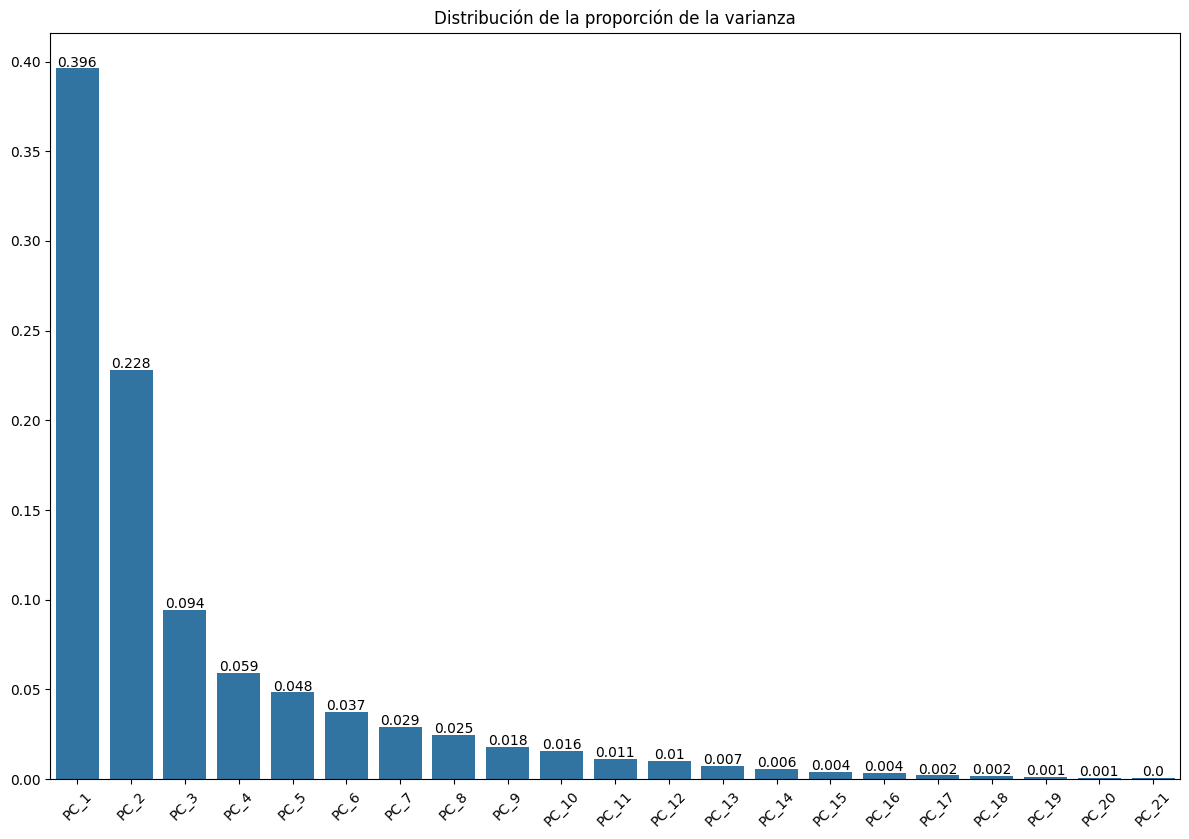

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA()
pca_result = pca.fit_transform(stats_scaler_df)

# Varianza explicada
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(12,8))
sns.barplot(x=[f"PC_{i+1}" for i in range(len(explained_variance))], y=explained_variance)
plt.tight_layout()
for i, pc in enumerate(explained_variance):
    plt.text(i, pc+0.001, s=str(round(pc,3)), ha="center")
plt.title("Distribución de la proporción de la varianza")
plt.xticks(rotation=45)
plt.show()

Según el gráfico de barras se infiere que ```PC1``` y ```PC2``` explican una parte significativa de la varianza total.

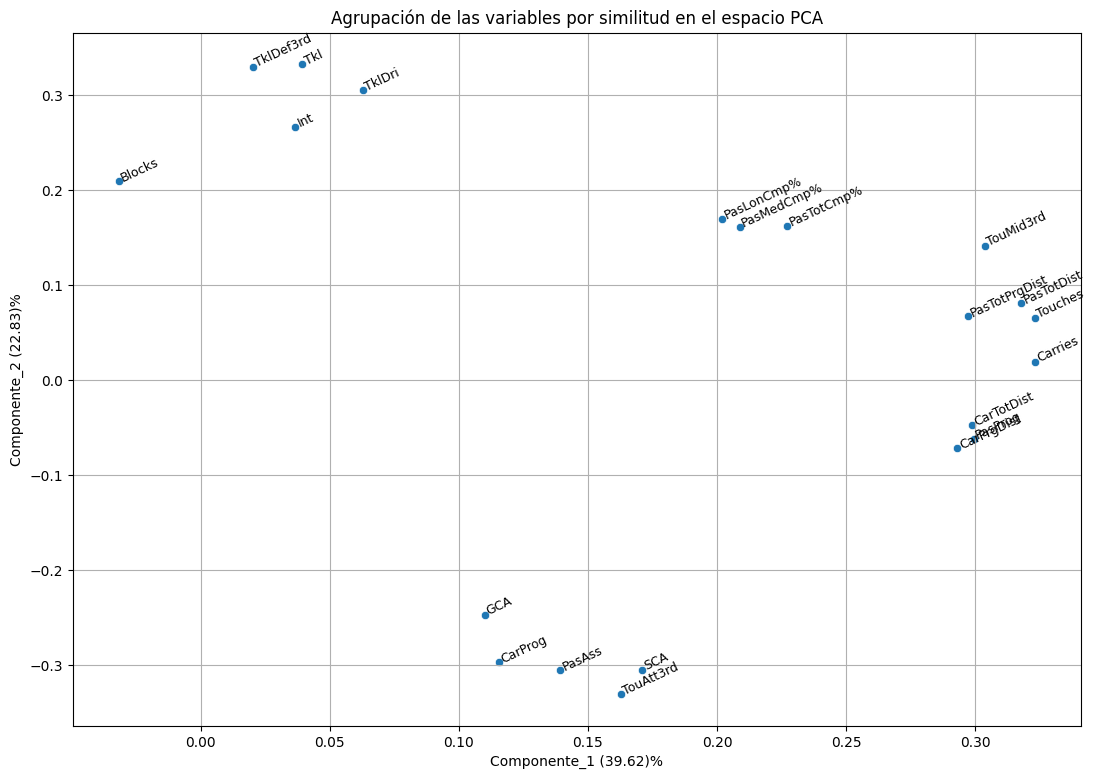

In [104]:
# seleccionando los 2 primeros componentes [:2]
componente_1_2 = pd.DataFrame(pca.components_[:2], index=["Componente_1","Componente_2"], columns=stats_scaler_df.columns)
plt.figure(figsize=(13, 9))
sns.scatterplot(data=componente_1_2, x=componente_1_2.loc["Componente_1"], y=componente_1_2.loc["Componente_2"])
for i in componente_1_2.columns:
    x = componente_1_2.loc["Componente_1", i]
    y = componente_1_2.loc["Componente_2", i]
    plt.text(x, y, i, fontsize=9, rotation=25)
plt.title("Agrupación de las variables por similitud en el espacio PCA")
plt.xlabel(f"Componente_1 ({explained_variance[0]*100:.2f})%")
plt.ylabel(f"Componente_2 ({explained_variance[1]*100:.2f})%")
plt.grid(True)
plt.show()

### Aplicación de KMeans para el agrupamiento en clústeres

In [105]:
# seleccionando los 2 primeros componentes [:2]
pca_result_df = pd.DataFrame(pca_result[:,:2], columns=["Componente_1", "Componente_2"])

### Método para encontrar el número de clústeres

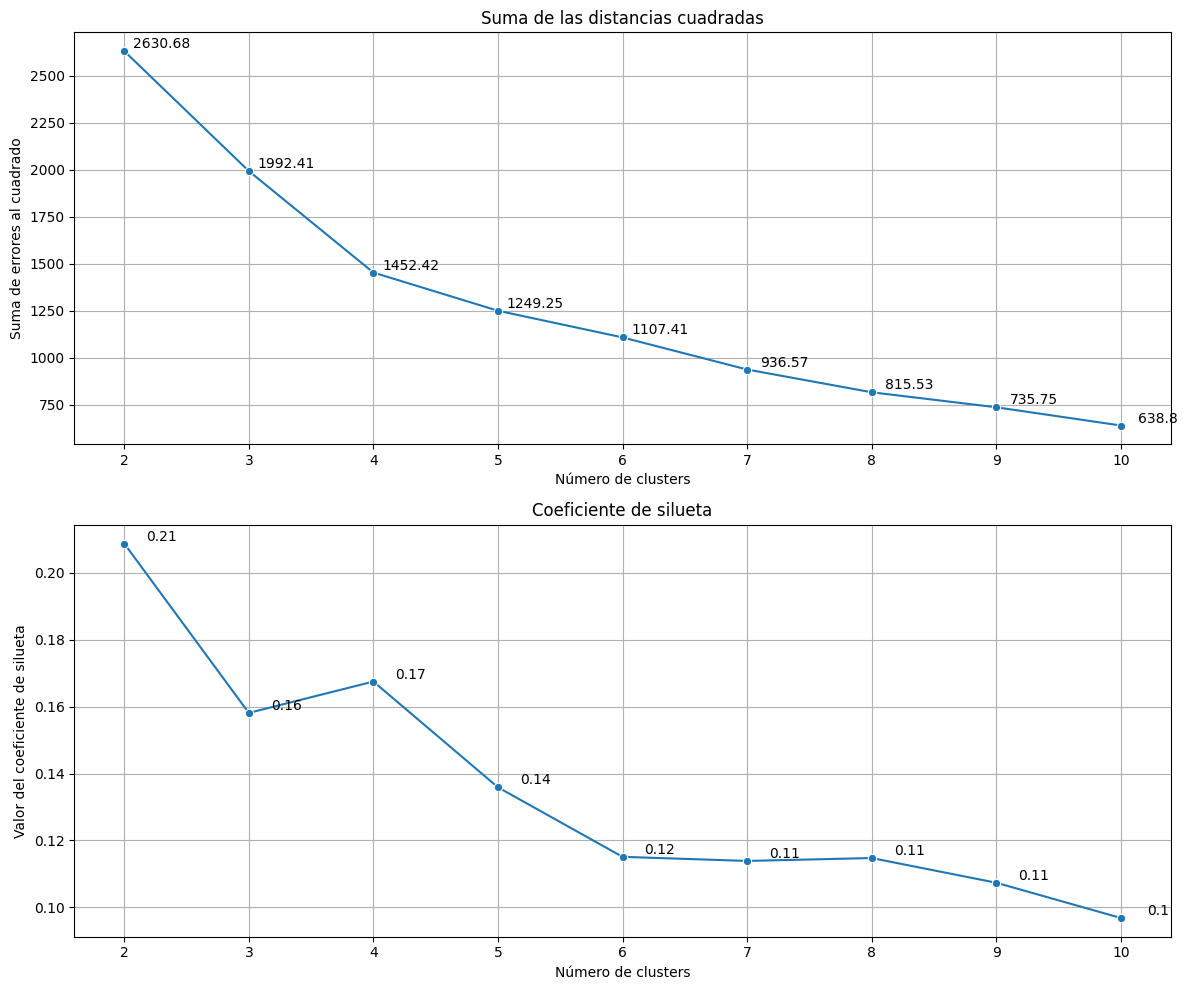

In [106]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

range_clusters = list(range(2, 11))
silhouette_scores = []
sum_squared_error = []
for n_cluster in range_clusters:
    kmeans_1 = KMeans(n_clusters=n_cluster)
    cluster_labels = kmeans_1.fit_predict(pca_result_df)
    sum_squared_error.append(kmeans_1.inertia_)
    silhouette_avg = silhouette_score(stats_scaler_df, cluster_labels)
    silhouette_scores.append(silhouette_avg)

fig, ax = plt.subplots(2, 1, figsize=(12,10))
ax = ax.flat
sns.lineplot(x=range_clusters, y=sum_squared_error, marker="o", ax=ax[0])
for x, y in zip(range_clusters, sum_squared_error):
    ax[0].text(x+0.3, y, str(round(y,2)), ha="center", va="bottom")
ax[0].set_title("Suma de las distancias cuadradas")
ax[0].set_xlabel("Número de clusters")
ax[0].set_ylabel("Suma de errores al cuadrado")
ax[0].grid(True)

sns.lineplot(x=range_clusters, y=silhouette_scores, marker="o", ax=ax[1])
for x, y in zip(range_clusters, silhouette_scores):
    ax[1].text(x+0.3, y, str(round(y,2)), ha="center", va="bottom")
ax[1].set_title("Coeficiente de silueta")
ax[1].set_xlabel("Número de clusters")
ax[1].set_ylabel("Valor del coeficiente de silueta")
ax[1].grid(True)
plt.tight_layout()
plt.show()

### En base que se busca una segmentación simple de Ofensivo y Defensivo se utilizará 2 clústeres. Aprovechando tambien que el valor más alto del coeficiente de silueta para 2 clústeres es 0.21.

0.3477579455284785


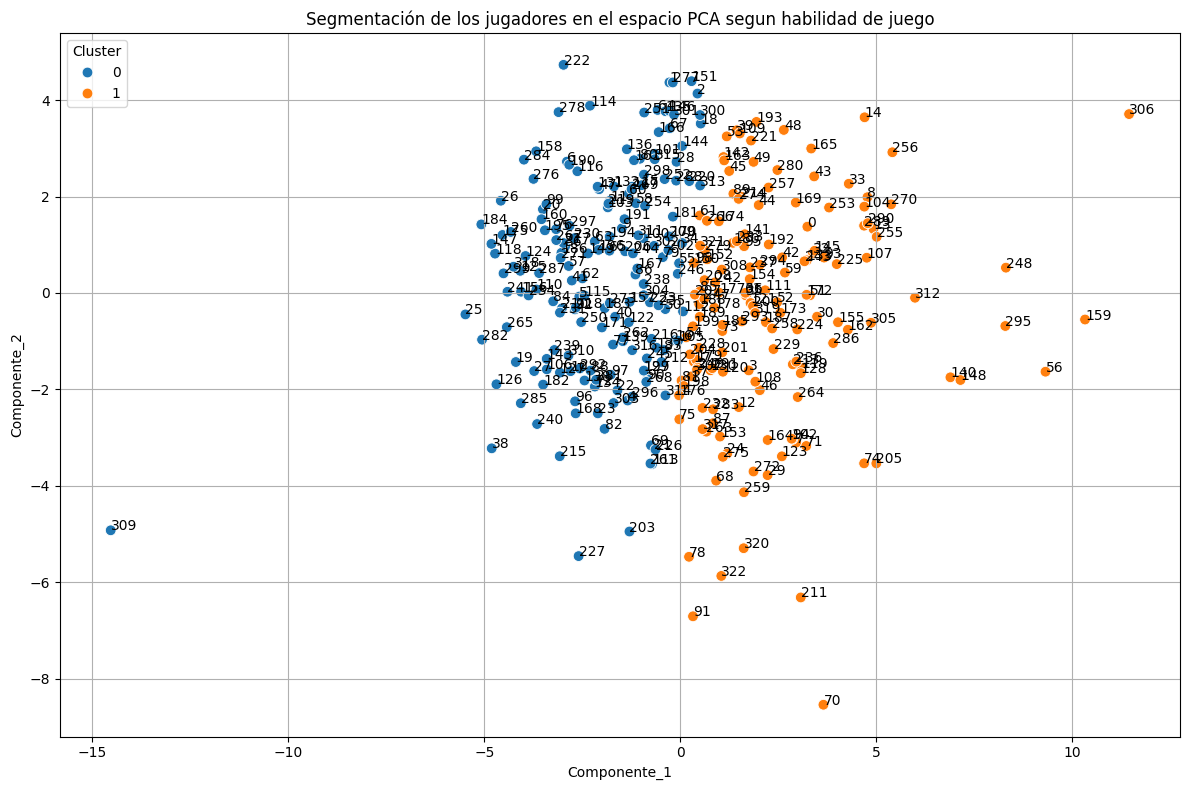

In [107]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Seleccionando el resultado de los 2 primeros componentes
kmeans = KMeans(n_clusters=2)
y_kmeans = kmeans.fit_predict(pca_result_df)
pca_result_df["Cluster"] = y_kmeans
pca_result_df["Jugador"] = df_players_filtered["Player"].reset_index(drop=True)

print(silhouette_score(pca_result_df[["Componente_1", "Componente_2"]], pca_result_df["Cluster"]))
plt.figure(figsize=(12, 8))
sns.scatterplot(data=pca_result_df, x='Componente_1', y='Componente_2', hue="Cluster", s=60)
for label, x, y in zip(pca_result_df.index,
                       pca_result_df["Componente_1"],
                       pca_result_df['Componente_2']):
    plt.text(x, y, label)
plt.title('Segmentación de los jugadores en el espacio PCA segun habilidad de juego')
plt.xlabel('Componente_1')
plt.ylabel('Componente_2')
plt.grid(True)
plt.tight_layout()
plt.show()

### Caraterísticas de cada Clúster

- Añadiendo los clústeres a los datos estadisticos estandarizados
- Agrupando los datos según los clústeres y obteniendo la media de cada variable según su clúster.
- Prepación de los datos para el análisis con ```melt```

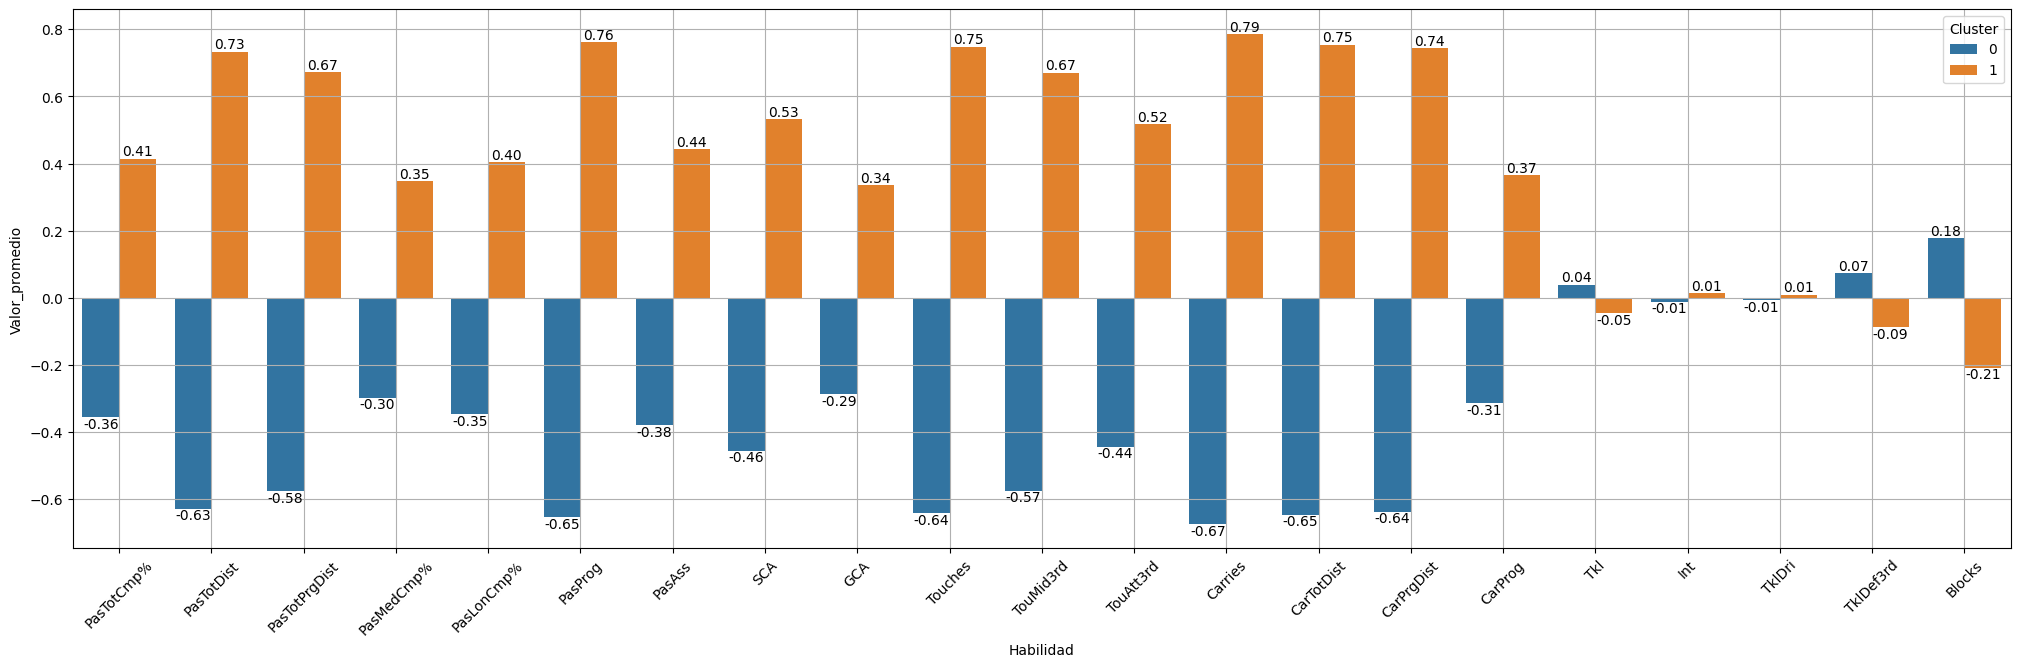

In [108]:
stats_scaler_df["Cluster"] = pca_result_df["Cluster"]
cluster_summary = stats_scaler_df.groupby("Cluster").mean()
cluster_summary_long = cluster_summary.reset_index().melt(id_vars="Cluster", var_name="Habilidad", value_name="Valor_promedio")

fig, ax1 = plt.subplots(figsize=(25, 7))
graf = sns.barplot(data=cluster_summary_long, x="Habilidad", y="Valor_promedio", hue="Cluster", ax=ax1)
for values in graf.containers:
    graf.bar_label(values, fmt="%.2f")  # Agrega etiquetas en el centro de las barras
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

## ¿Qué representa este gráfico?

Las barras positivas indican que esa habilidad está más presente en ese clúster.
Las barras negativas indican que esa habilidad está menos presente o tiene una relación negativa con ese clúster.

Que habilidad es más representativa en cada clúster:

- **Clúster 0**: Se puede inferir que agrupa jugadores con alta participación en acciones defensivas, especialmente en el tercio defensivo
                (zonas cercanas al propio arco).
    - ```Tkl``` (Jugadores a los que se les hizo una entrada defensiva)
    - ```TklDef3rd```	(Entradas en el tercio defensivo)
    - ```Blocks``` (Veces que se bloqueó el balón)

- **Clúster 1**: Se puede inferir que agrupa jugadores con participación activa en la creación de jugadas ofensivas,
                incluyendo pases, conducciones y acciones que generan tiros o goles.
    - **Pases efectivos y progresivos**
    - ```PasTotCmp%``` (Porcentaje de pases completados)
    - ```PasTotDist``` (Distancia total en yardas de los pases completados en cualquier dirección)
    - ```PasTotPrgDist``` (Distancia total en yardas de los pases completados hacia el arco rival)
    - ```PasMedCmp%``` (Porcentaje de pases completados (entre 15 y 30 yardas))
    - ```PasLonCmp%``` (Porcentaje de pases completados, más de 30 yardas)
    - ```PasProg``` (Pases completados que avanzan al menos 10 yardas hacia el arco rival o ingresan al área)

    - **Generación de oportunidades de gol**
    - ```PasAss``` (Pases que conducen directamente a un tiro)
    - ```SCA``` (Acciones que generan tiros)
    - ```GCA``` (Acciones que generan goles)

    - **Aporte ofensivo**
    - ```Touches``` (Toques del balón)
    - ```TouMid3rd``` (Toques en el tercio medio)
    - ```TouAtt3rd```	(Toques en el tercio ofensivo)
    - ```Carries``` (Conducciones del balón)
    - ```CarTotDist``` (Distancia total conducida con el balón)
    - ```CarPrgDist``` (Distancia conducida hacia el arco rival)
    - ```CarProg``` (Conducciones que avanzan al menos 5 yardas o ingresan al área)

    - **Aporte defensivo**
    - ```TklDri``` (Regateadores a los que se les hizo una entrada)
    - ```Int``` (Intercepciones)

